# EDA — creditcard.csv (Bank Credit Card Transactions)

**Goal:** Understand the anonymized PCA-transformed credit card dataset and its fraud patterns.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

DATA_PATH = 'data/raw/creditcard.csv'

## 1. Load Data

In [2]:
df = pd.read_csv(DATA_PATH)
print(f'Shape: {df.shape}')
df.head()

Shape: (284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [3]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

## 2. Data Cleaning

In [4]:
print('Missing values:')
print(df.isnull().sum())
print(f'\nDuplicates: {df.duplicated().sum()}')
df.drop_duplicates(inplace=True)

Missing values:
Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

Duplicates: 1081


## 3. Class Imbalance

Class distribution:
        count  percent
Class                 
0      283253  99.8333
1         473   0.1667


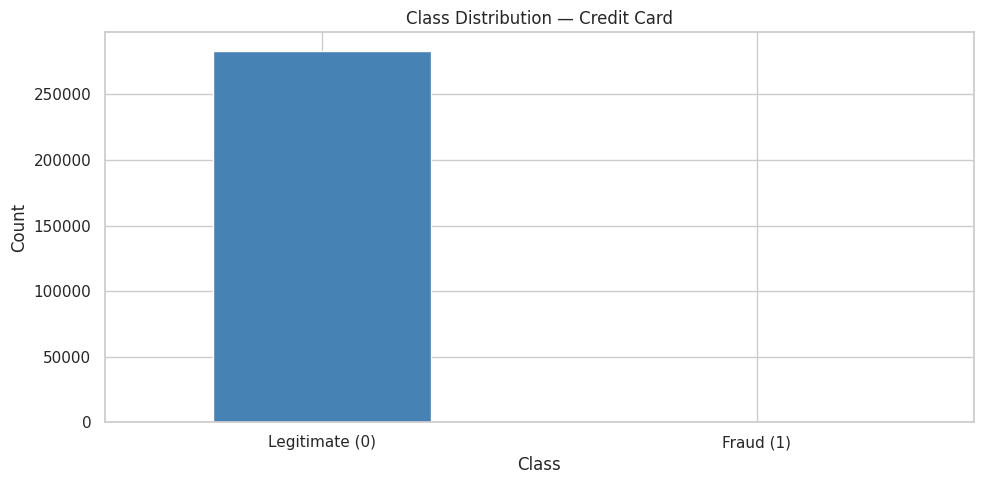

In [5]:
class_counts = df['Class'].value_counts()
class_pct = df['Class'].value_counts(normalize=True) * 100

print('Class distribution:')
print(pd.DataFrame({'count': class_counts, 'percent': class_pct.round(4)}))

fig, ax = plt.subplots()
class_counts.plot(kind='bar', ax=ax, color=['steelblue', 'tomato'])
ax.set_xticklabels(['Legitimate (0)', 'Fraud (1)'], rotation=0)
ax.set_title('Class Distribution — Credit Card')
ax.set_ylabel('Count')
plt.tight_layout()
plt.savefig('data/processed/class_dist_creditcard.png', dpi=150)
plt.show()

## 4. Univariate Analysis

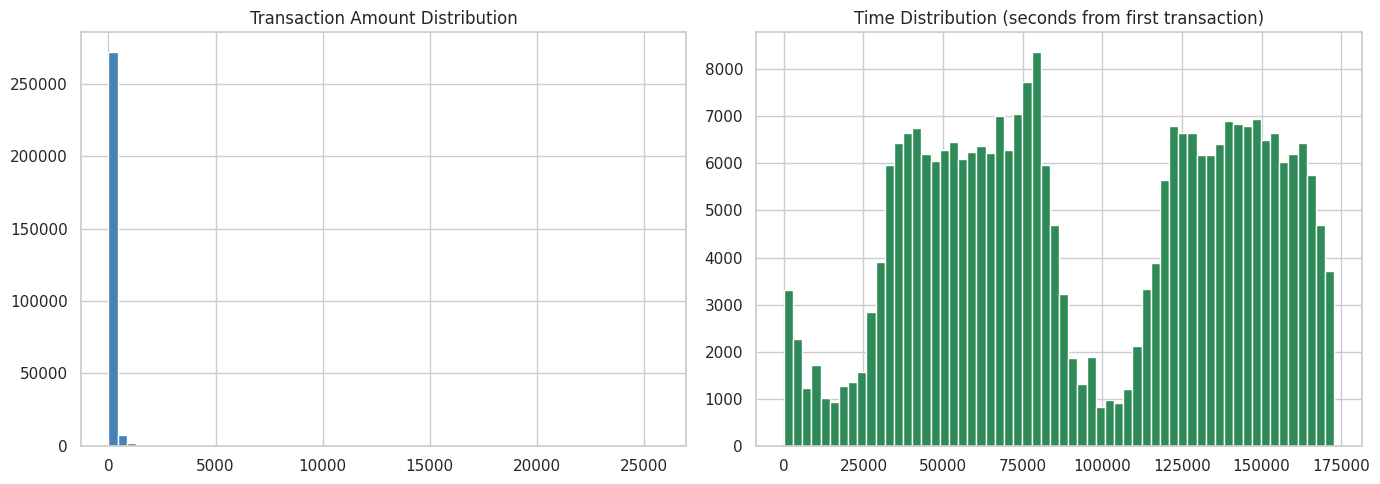

In [6]:
# Amount and Time distributions
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
df['Amount'].hist(bins=60, ax=axes[0], color='steelblue')
axes[0].set_title('Transaction Amount Distribution')
df['Time'].hist(bins=60, ax=axes[1], color='seagreen')
axes[1].set_title('Time Distribution (seconds from first transaction)')
plt.tight_layout()
plt.show()

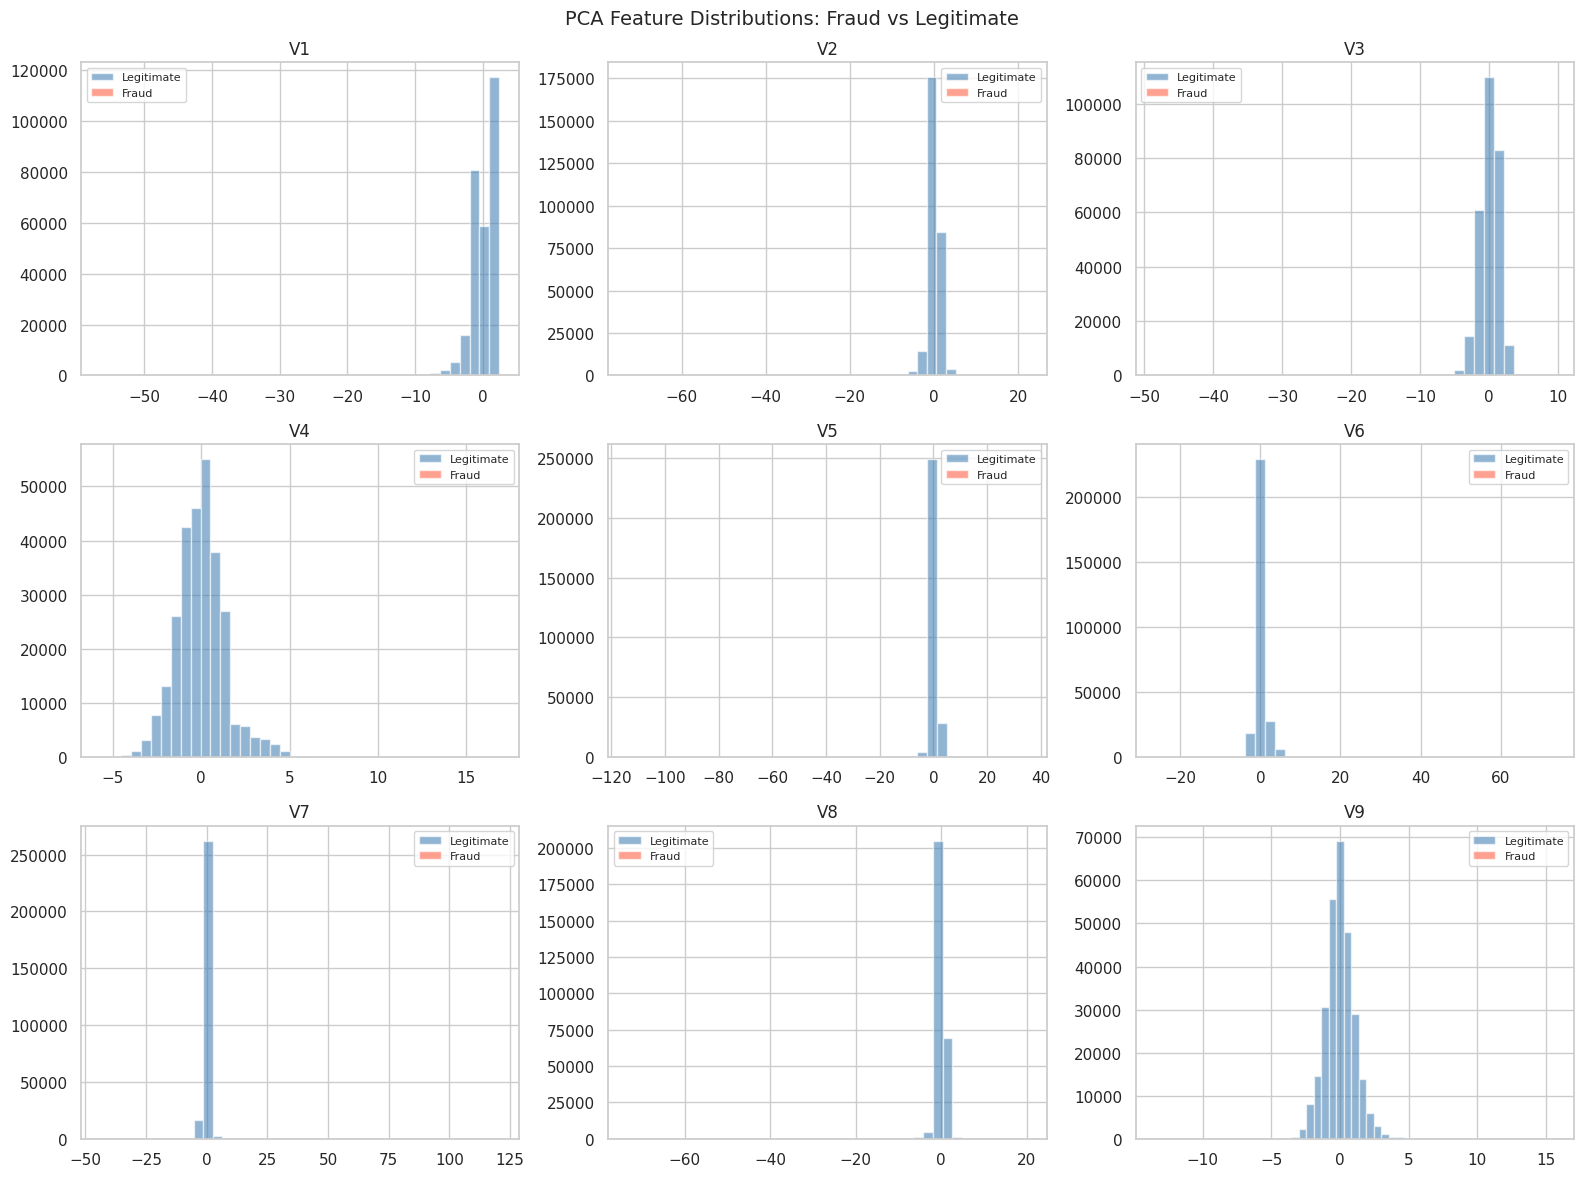

In [7]:
# Distribution of PCA features by class
v_cols = [f'V{i}' for i in range(1, 10)]  # sample first 9
fig, axes = plt.subplots(3, 3, figsize=(16, 12))
for ax, col in zip(axes.flatten(), v_cols):
    df[df['Class'] == 0][col].hist(bins=40, ax=ax, alpha=0.6, label='Legitimate', color='steelblue')
    df[df['Class'] == 1][col].hist(bins=40, ax=ax, alpha=0.6, label='Fraud', color='tomato')
    ax.set_title(col)
    ax.legend(fontsize=8)
plt.suptitle('PCA Feature Distributions: Fraud vs Legitimate', fontsize=14)
plt.tight_layout()
plt.show()

## 5. Bivariate Analysis

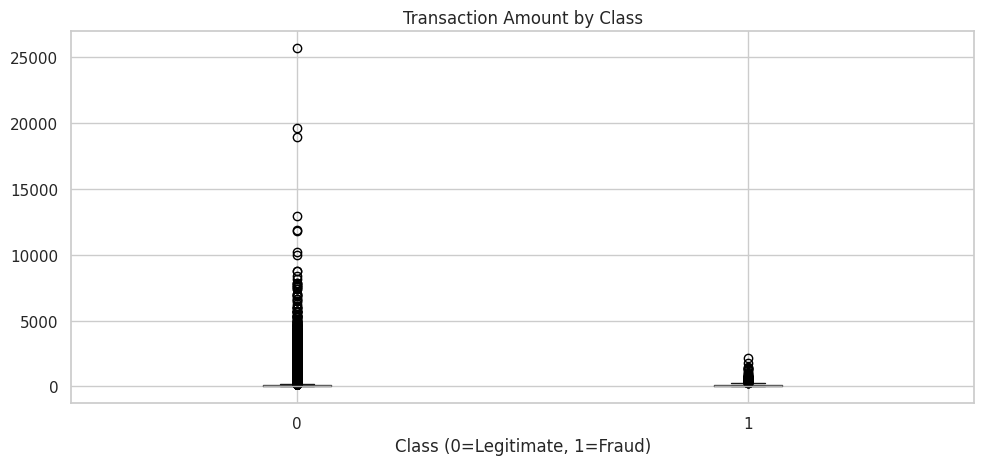

In [8]:
# Amount by class
fig, ax = plt.subplots()
df.boxplot(column='Amount', by='Class', ax=ax)
ax.set_title('Transaction Amount by Class')
ax.set_xlabel('Class (0=Legitimate, 1=Fraud)')
plt.suptitle('')
plt.tight_layout()
plt.show()

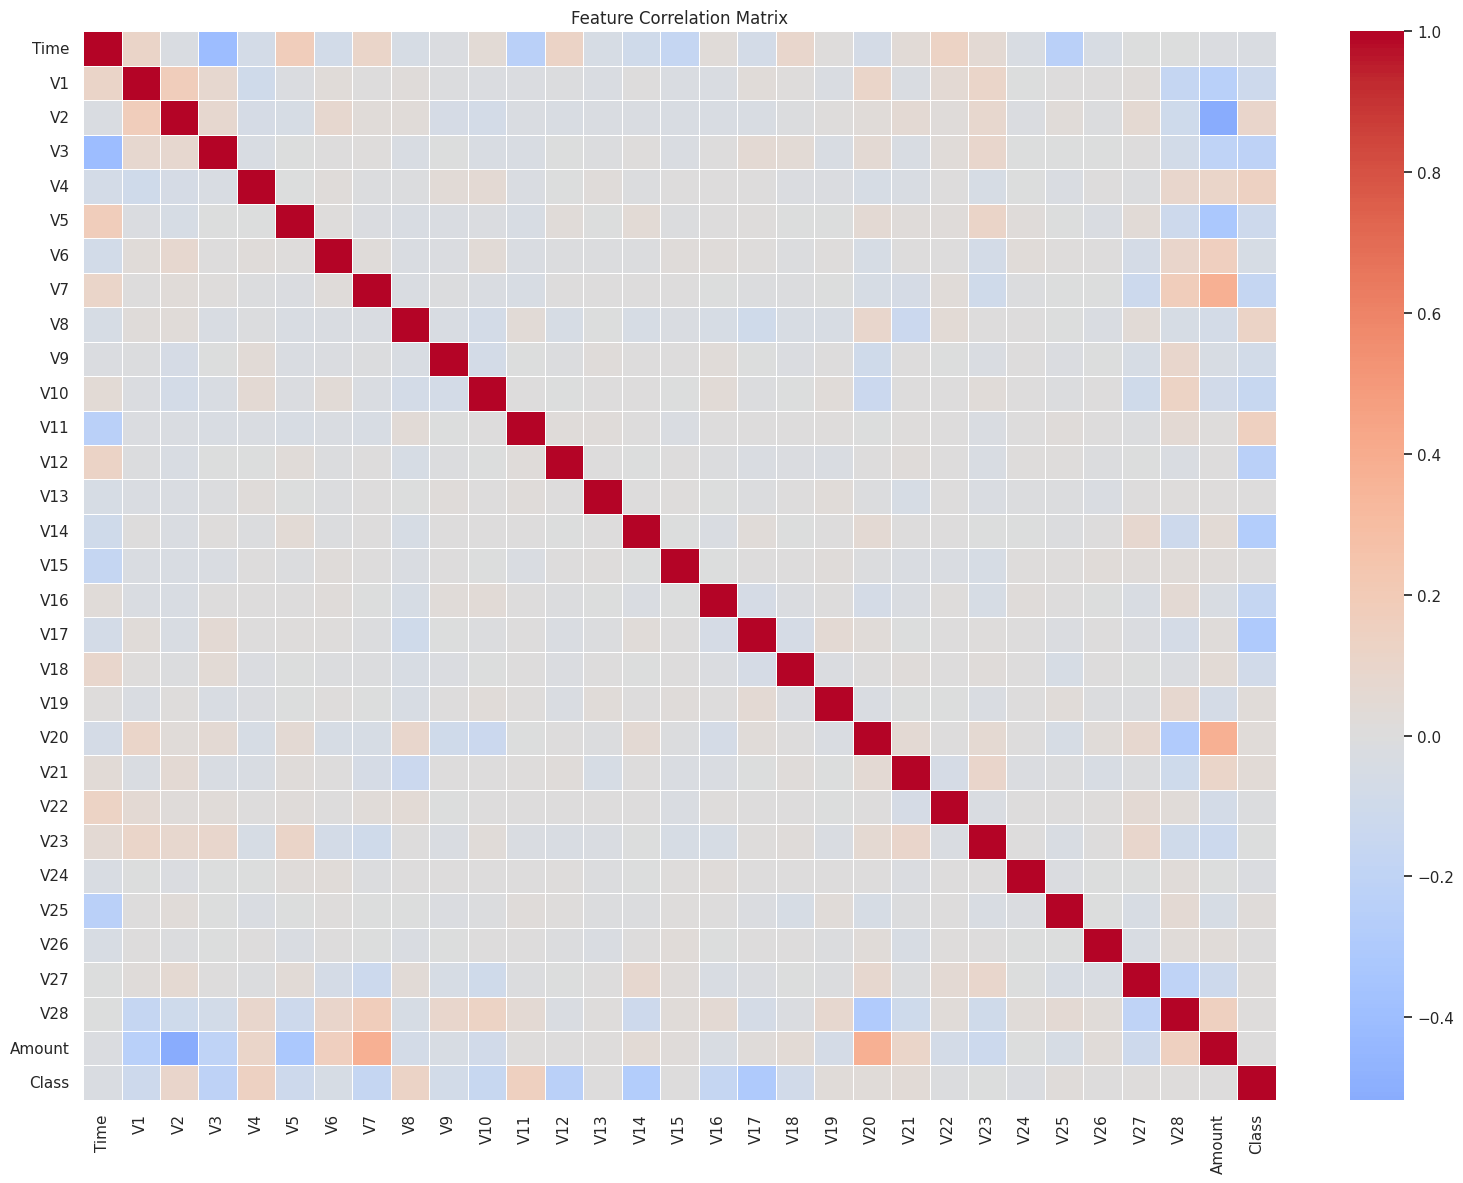

In [9]:
# Correlation heatmap (sampled to keep it readable)
sample = df.sample(5000, random_state=42)
corr = sample.corr()
fig, ax = plt.subplots(figsize=(16, 12))
sns.heatmap(corr, cmap='coolwarm', center=0, ax=ax, linewidths=0.5)
ax.set_title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

## 6. Save Cleaned Data

In [10]:
df.to_csv('data/processed/creditcard_cleaned.csv', index=False)
print('Saved to data/processed/creditcard_cleaned.csv')

Saved to data/processed/creditcard_cleaned.csv
